In [1]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt

from mne.decoding import CSP

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, f1_score

In [2]:
# ==============================
# CONFIGURATION
# ==============================

data_folder = "../data/BCI_IV_2a"

subjects = [
    "A01",
    "A02",
    "A03",
    "A04",
    "A05",
    "A06",
    "A07",
    "A08",
    "A09"
]

# Fixed OUTPUT labels used throughout this notebook.
# IMPORTANT: MNE assigns per-file numeric codes to annotation
# descriptions based on which descriptions appear in that specific
# file and in what order -- the same description (e.g. "769") can get
# a DIFFERENT numeric code in different subjects' files (confirmed for
# A04T in A04T_Investigation.ipynb). We always look codes up by
# description string per file (see loading cell below) and translate
# them to this fixed set of output labels, so labels are consistent
# across every subject.
DESC_TO_LABEL = {
    "769": 7,   # LEFT
    "770": 8,   # RIGHT
    "771": 9,   # FOOT
    "772": 10,  # TONGUE
}

# Epoch
TMIN = 1.0
TMAX = 3.0

# Sampling frequency
SFREQ = 250

# FBCSP frequency bands
FREQUENCY_BANDS = [
    (8, 12),
    (12, 16),
    (16, 20),
    (20, 24),
    (24, 28),
    (28, 32)
]

# Number of CSP components per frequency band
N_CSP_COMPONENTS = 4

print("Frequency bands:")
for band in FREQUENCY_BANDS:
    print(f"{band[0]}-{band[1]} Hz")

print("\nEpoch:", TMIN, "to", TMAX, "seconds")
print("CSP components per band:", N_CSP_COMPONENTS)


Frequency bands:
8-12 Hz
12-16 Hz
16-20 Hz
20-24 Hz
24-28 Hz
28-32 Hz

Epoch: 1.0 to 3.0 seconds
CSP components per band: 4


In [3]:
# ==============================
# CHECK DATASET
# ==============================

for subject in subjects:

    file_path = os.path.join(
        data_folder,
        subject + "T.gdf"
    )

    if os.path.exists(file_path):
        print("FOUND:", file_path)
    else:
        print("MISSING:", file_path)

FOUND: ../data/BCI_IV_2a\A01T.gdf
FOUND: ../data/BCI_IV_2a\A02T.gdf
FOUND: ../data/BCI_IV_2a\A03T.gdf
FOUND: ../data/BCI_IV_2a\A04T.gdf
FOUND: ../data/BCI_IV_2a\A05T.gdf
FOUND: ../data/BCI_IV_2a\A06T.gdf
FOUND: ../data/BCI_IV_2a\A07T.gdf
FOUND: ../data/BCI_IV_2a\A08T.gdf
FOUND: ../data/BCI_IV_2a\A09T.gdf


In [4]:
# ==============================
# LOAD ALL SUBJECTS
# ==============================

X_list = []
y_list = []
groups_list = []

for subject in subjects:

    print("\n==============================")
    print("SUBJECT:", subject)
    print("==============================")

    file_path = os.path.join(
        data_folder,
        subject + "T.gdf"
    )

    print("Loading:", file_path)

    raw = mne.io.read_raw_gdf(
        file_path,
        preload=True,
        verbose=False
    )

    # Keep EEG channels only
    raw.pick_types(
        eeg=True
    )

    # Find events. event_dict maps annotation DESCRIPTION -> per-file
    # numeric code. We must look codes up by description, not assume
    # a fixed value (see DESC_TO_LABEL cell above).
    events, event_dict = mne.events_from_annotations(
        raw,
        verbose=False
    )

    print("Available events:")
    print(event_dict)

    # Build this subject's event_id using description strings
    available_events = {
        desc: event_dict[desc]
        for desc in DESC_TO_LABEL
        if desc in event_dict
    }

    if len(available_events) != 4:
        missing = set(DESC_TO_LABEL) - set(available_events)
        print(f"WARNING: {subject} missing motor-imagery events: {missing}")

    print("Using:")
    print(available_events)

    # Create 1-3 second epochs
    epochs = mne.Epochs(
        raw,
        events,
        event_id=available_events,
        tmin=TMIN,
        tmax=TMAX,
        baseline=None,
        preload=True,
        verbose=False
    )

    X = epochs.get_data()

    # Remap this subject's per-file codes to the fixed output labels
    code_to_label = {
        event_dict[desc]: DESC_TO_LABEL[desc]
        for desc in available_events
    }
    y = np.array([code_to_label[code] for code in epochs.events[:, -1]])

    # Keep the first 22 EEG channels
    X = X[:, :22, :]

    print("Epoch data:", X.shape)
    print("Labels:", y.shape)
    print("Class counts:", dict(zip(*np.unique(y, return_counts=True))))

    X_list.append(X)
    y_list.append(y)

    groups_list.extend(
        [subject] * len(y)
    )


# Combine all subjects
X_all = np.concatenate(
    X_list,
    axis=0
)

y_all = np.concatenate(
    y_list,
    axis=0
)

groups = np.array(
    groups_list
)

print("\n================================")
print("COMBINED DATASET")
print("================================")

print("X_all:", X_all.shape)
print("y_all:", y_all.shape)
print("groups:", groups.shape)

print("\nClass distribution:")
print(
    np.unique(
        y_all,
        return_counts=True
    )
)

print("\nSubject distribution:")
print(
    np.unique(
        groups,
        return_counts=True
    )
)



SUBJECT: A01
Loading: ../data/BCI_IV_2a\A01T.gdf


C:\Users\chahi\AppData\Local\Python\pythoncore-3.11-64\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Available events:
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Using:
{'769': 7, '770': 8, '771': 9, '772': 10}
Epoch data: (288, 22, 501)
Labels: (288,)
Class counts: {np.int64(7): np.int64(72), np.int64(8): np.int64(72), np.int64(9): np.int64(72), np.int64(10): np.int64(72)}

SUBJECT: A02
Loading: ../data/BCI_IV_2a\A02T.gdf


C:\Users\chahi\AppData\Local\Python\pythoncore-3.11-64\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Available events:
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Using:
{'769': 7, '770': 8, '771': 9, '772': 10}
Epoch data: (288, 22, 501)
Labels: (288,)
Class counts: {np.int64(7): np.int64(72), np.int64(8): np.int64(72), np.int64(9): np.int64(72), np.int64(10): np.int64(72)}

SUBJECT: A03
Loading: ../data/BCI_IV_2a\A03T.gdf


...

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Available events:
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Using:
{'769': 7, '770': 8, '771': 9, '772': 10}
Epoch data: (288, 22, 501)
Labels: (288,)
Class counts: {np.int64(7): np.int64(72), np.int64(8): np.int64(72), np.int64(9): np.int64(72), np.int64(10): np.int64(72)}

SUBJECT: A08
Loading: ../data/BCI_IV_2a\A08T.gdf


C:\Users\chahi\AppData\Local\Python\pythoncore-3.11-64\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Available events:
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Using:
{'769': 7, '770': 8, '771': 9, '772': 10}
Epoch data: (288, 22, 501)
Labels: (288,)
Class counts: {np.int64(7): np.int64(72), np.int64(8): np.int64(72), np.int64(9): np.int64(72), np.int64(10): np.int64(72)}

SUBJECT: A09
Loading: ../data/BCI_IV_2a\A09T.gdf


C:\Users\chahi\AppData\Local\Python\pythoncore-3.11-64\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Available events:
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Using:
{'769': 7, '770': 8, '771': 9, '772': 10}
Epoch data: (288, 22, 501)
Labels: (288,)
Class counts: {np.int64(7): np.int64(72), np.int64(8): np.int64(72), np.int64(9): np.int64(72), np.int64(10): np.int64(72)}

COMBINED DATASET
X_all: (2592, 22, 501)
y_all: (2592,)
groups: (2592,)

Class distribution:
(array([ 7,  8,  9, 10]), array([648, 648, 648, 648]))

Subject distribution:
(array(['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09'],
      dtype='<U3'), array([288, 288, 288, 288, 288, 288, 288, 288, 288]))


In [5]:
# ==============================
# VERIFY LABELS
# ==============================

print("Unique labels:", np.unique(y_all))

print(
    "Label counts:",
    np.unique(
        y_all,
        return_counts=True
    )
)

print(
    "Unique subjects:",
    np.unique(groups)
)

Unique labels: [ 7  8  9 10]
Label counts: (array([ 7,  8,  9, 10]), array([648, 648, 648, 648]))
Unique subjects: ['A01' 'A02' 'A03' 'A04' 'A05' 'A06' 'A07' 'A08' 'A09']


In [6]:
# ==============================
# FBCSP FEATURE EXTRACTION
# ==============================

def extract_fbcsp_features(
    X_train,
    y_train,
    X_test
):

    train_features = []
    test_features = []

    csp_models = []

    for low_freq, high_freq in FREQUENCY_BANDS:

        print(
            f"Processing band "
            f"{low_freq}–{high_freq} Hz"
        )

        # --------------------------
        # Filter training data
        # --------------------------

        X_train_band = np.empty_like(
            X_train
        )

        for i in range(
            X_train.shape[0]
        ):

            X_train_band[i] = mne.filter.filter_data(
                X_train[i],
                sfreq=SFREQ,
                l_freq=low_freq,
                h_freq=high_freq,
                verbose=False
            )

        # --------------------------
        # Filter test data
        # --------------------------

        X_test_band = np.empty_like(
            X_test
        )

        for i in range(
            X_test.shape[0]
        ):

            X_test_band[i] = mne.filter.filter_data(
                X_test[i],
                sfreq=SFREQ,
                l_freq=low_freq,
                h_freq=high_freq,
                verbose=False
            )

        # --------------------------
        # CSP
        # --------------------------

        csp = CSP(
            n_components=N_CSP_COMPONENTS,
            reg=None,
            log=True,
            norm_trace=False
        )

        # Fit ONLY on training data
        X_train_csp = csp.fit_transform(
            X_train_band,
            y_train
        )

        # Transform test data
        X_test_csp = csp.transform(
            X_test_band
        )

        train_features.append(
            X_train_csp
        )

        test_features.append(
            X_test_csp
        )

        csp_models.append(
            csp
        )

    # --------------------------
    # Combine all bands
    # --------------------------

    X_train_features = np.concatenate(
        train_features,
        axis=1
    )

    X_test_features = np.concatenate(
        test_features,
        axis=1
    )

    return (
        X_train_features,
        X_test_features,
        csp_models
    )

In [7]:
# ==============================
# TEST FBCSP ON A01
# ==============================

train_mask = groups != "A01"
test_mask = groups == "A01"

X_train = X_all[train_mask]
X_test = X_all[test_mask]

y_train = y_all[train_mask]
y_test = y_all[test_mask]

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

X_train_fbcsp, X_test_fbcsp, _ = extract_fbcsp_features(
    X_train,
    y_train,
    X_test
)

print(
    "\nFBCSP training features:",
    X_train_fbcsp.shape
)

print(
    "FBCSP testing features:",
    X_test_fbcsp.shape
)

Training: (2304, 22, 501)
Testing : (288, 22, 501)
Processing band 8–12 Hz
Computing rank from data with rank=None
    Using tolerance 0.00012 (2.2e-16 eps * 22 dim * 2.5e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Estimating class=9 covariance using EMPIRICAL
Done.
Estimating class=10 covariance using EMPIRICAL
Done.
Processing band 12–16 Hz
Computing rank from data with rank=None
    Using tolerance 8.2e-05 (2.2e-16 eps * 22 dim * 1.7e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Estimating class=9 covariance using EMPIRICAL
Done.
Estimating class=10 covariance us

In [8]:
# ==============================
# A01 FBCSP + LDA
# ==============================

lda = LinearDiscriminantAnalysis()

lda.fit(
    X_train_fbcsp,
    y_train
)

y_pred = lda.predict(
    X_test_fbcsp
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(
    "A01 FBCSP + LDA Accuracy:",
    accuracy * 100,
    "%"
)

print(
    "A01 Macro F1:",
    macro_f1
)

A01 FBCSP + LDA Accuracy: 42.70833333333333 %
A01 Macro F1: 0.3402657622051577


In [10]:
# ==============================
# FULL FBCSP LOSO
# ==============================

logo = LeaveOneGroupOut()

fold_results = []

for train_idx, test_idx in logo.split(
    X_all,
    y_all,
    groups=groups
):

    held_out_subject = groups[test_idx[0]]

    print("\n")
    print("================================")
    print(
        "HELD-OUT SUBJECT:",
        held_out_subject
    )
    print("================================")

    X_train = X_all[train_idx]
    X_test = X_all[test_idx]

    y_train = y_all[train_idx]
    y_test = y_all[test_idx]

    print(
        "Training trials:",
        len(y_train)
    )

    print(
        "Testing trials:",
        len(y_test)
    )

    # --------------------------
    # FBCSP
    # --------------------------

    X_train_fbcsp, X_test_fbcsp, _ = extract_fbcsp_features(
        X_train,
        y_train,
        X_test
    )

    print(
        "FBCSP features:",
        X_train_fbcsp.shape
    )

    # --------------------------
    # LDA
    # --------------------------

    lda = LinearDiscriminantAnalysis()

    lda.fit(
        X_train_fbcsp,
        y_train
    )

    y_pred = lda.predict(
        X_test_fbcsp
    )

    # --------------------------
    # Metrics
    # --------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    fold_results.append(
        (
            held_out_subject,
            accuracy,
            macro_f1
        )
    )

    print(
        f"{held_out_subject} Accuracy: "
        f"{accuracy * 100:.2f}%"
    )

    print(
        f"{held_out_subject} Macro F1: "
        f"{macro_f1:.4f}"
    )



HELD-OUT SUBJECT: A01
Training trials: 2304
Testing trials: 288
Processing band 8–12 Hz
Computing rank from data with rank=None
    Using tolerance 0.00012 (2.2e-16 eps * 22 dim * 2.5e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Estimating class=9 covariance using EMPIRICAL
Done.
Estimating class=10 covariance using EMPIRICAL
Done.
Processing band 12–16 Hz
Computing rank from data with rank=None
    Using tolerance 8.2e-05 (2.2e-16 eps * 22 dim * 1.7e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Estimating class=9 covariance using EMPIRICAL
Done.
Estimating class=1

In [11]:
# ==============================
# FINAL FBCSP RESULTS
# ==============================

accuracies = [
    result[1]
    for result in fold_results
]

f1_scores = [
    result[2]
    for result in fold_results
]

print("\n")
print("================================")
print("FINAL FBCSP LOSO RESULTS")
print("================================")

for subject, accuracy, f1 in fold_results:

    print(
        f"{subject}: "
        f"{accuracy * 100:.2f}% | "
        f"F1: {f1:.4f}"
    )

print("\n================================")

print(
    f"Mean Accuracy: "
    f"{np.mean(accuracies) * 100:.2f}%"
)

print(
    f"Std Accuracy: "
    f"{np.std(accuracies) * 100:.2f}%"
)

print(
    f"Mean Macro F1: "
    f"{np.mean(f1_scores):.4f}"
)



FINAL FBCSP LOSO RESULTS
A01: 42.71% | F1: 0.3403
A02: 24.31% | F1: 0.2281
A03: 52.08% | F1: 0.4680
A04: 37.50% | F1: 0.3261
A05: 22.22% | F1: 0.1197
A06: 31.94% | F1: 0.2398
A07: 30.56% | F1: 0.2236
A08: 45.49% | F1: 0.4012
A09: 48.26% | F1: 0.4510

Mean Accuracy: 37.23%
Std Accuracy: 10.03%
Mean Macro F1: 0.3108


In [12]:
# ==============================
# COMPARISON
# ==============================

previous_results = {
    "CSP + LDA": 38.31,
    "CSP + Normalization + LDA": 40.90,
    "FBCSP + LDA": np.mean(accuracies) * 100
}

print("\n================================")
print("METHOD COMPARISON")
print("================================")

for method, accuracy in previous_results.items():

    print(
        f"{method}: "
        f"{accuracy:.2f}%"
    )



METHOD COMPARISON
CSP + LDA: 38.31%
CSP + Normalization + LDA: 40.90%
FBCSP + LDA: 37.23%


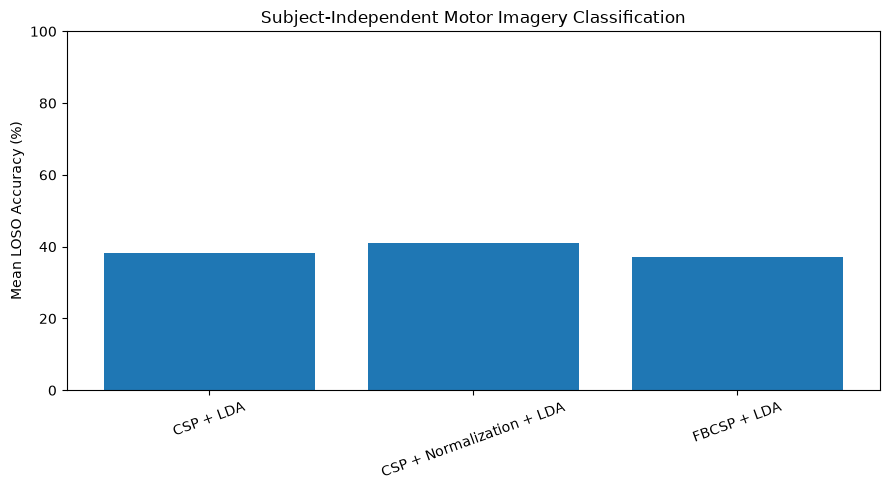

In [13]:
# ==============================
# PLOT COMPARISON
# ==============================

methods = list(
    previous_results.keys()
)

values = list(
    previous_results.values()
)

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    methods,
    values
)

plt.ylabel(
    "Mean LOSO Accuracy (%)"
)

plt.title(
    "Subject-Independent Motor Imagery Classification"
)

plt.xticks(
    rotation=20
)

plt.ylim(
    0,
    100
)

plt.tight_layout()

plt.show()